# Spatial Intelligence — Request 1
## Which gas stations violate the new school-distance rule, and where could they relocate?

You are a **remote consultant on spatial intelligence**. A municipal council has changed a rule affecting gas stations:

> A gas station cannot operate within **100 meters of a school**.

The municipality asks two questions:

1. **Which existing gas stations are now in a prohibited location?**
2. **Where could the affected stations relocate?**

The 100-meter threshold is a **workshop scenario**, not a statement of current Boston law.

The notebook is organized around the decision problem rather than around GIS commands. We will learn projection, distance, buffers, spatial joins, overlay, and proximity because each operation is needed to answer the client's request.

## 1. Getting ready

We use:

- **GeoPandas** for spatial tables and operations;
- **OSMnx** for schools, gas stations, and streets from OpenStreetMap;
- **Shapely** for geometric operations;
- **Matplotlib** for static maps.

In Google Colab, uncomment the installation line if needed.

In [1]:
# !pip install -q geopandas osmnx mapclassify folium

import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import osmnx as ox

from shapely.ops import nearest_points

## 2. Load the municipal boundary

Distance calculations require a **projected coordinate reference system (CRS)** with meaningful linear units.

The Boston municipal boundary used in the original example is already provided in a Massachusetts projected CRS.

In [2]:
boston_url = (
    "https://github.com/CienciaDeDatosEspacial/dataSets/"
    "raw/refs/heads/main/BOSTON/GISDATA.TOWNSSURVEY_POLYM.zip"
)

boston = gpd.read_file(boston_url)

print("CRS:", boston.crs)
print("Projected:", boston.crs.is_projected)
boston

CRS: EPSG:26986
Projected: True


,town,town_id,type,county,fips_stco,fourcolor,pop1960,pop1970,pop1980,pop1990,pop2000,pop2010,pop2020,popch10_20,area_acres,area_sqmi,geometry
0,BOSTON,35,C,SUFFOLK,25025,1,697197,641071,562994,574283,588957,617594,675647,58053,32104.34973,50.15997,"MULTIPOLYGON (((235056.153 904531.255, 235060...."


## 3. Retrieve schools and gas stations

OpenStreetMap contains several geometry types. A school or gas station may be represented as a point, polygon, or multipolygon.

We preserve those geometries rather than forcing everything to points immediately.

In [3]:
place = "Boston, Massachusetts, USA"

stations_raw = ox.features_from_place(
    place,
    tags={"amenity": "fuel"}
)

schools_raw = ox.features_from_place(
    place,
    tags={"amenity": "school"}
)

print("Gas stations:", len(stations_raw))
print("Schools:", len(schools_raw))

/opt/anaconda3/envs/papersPremier/lib/python3.12/site-packages/shapely/predicates.py:878: RuntimeWarning: invalid value encountered in intersects
  return lib.intersects(a, b, **kwargs)
/opt/anaconda3/envs/papersPremier/lib/python3.12/site-packages/shapely/set_operations.py:451: RuntimeWarning: invalid value encountered in union
  return lib.union(a, b, **kwargs)


Gas stations: 53
Schools: 273


/opt/anaconda3/envs/papersPremier/lib/python3.12/site-packages/shapely/predicates.py:878: RuntimeWarning: invalid value encountered in intersects
  return lib.intersects(a, b, **kwargs)
/opt/anaconda3/envs/papersPremier/lib/python3.12/site-packages/shapely/set_operations.py:451: RuntimeWarning: invalid value encountered in union
  return lib.union(a, b, **kwargs)
/opt/anaconda3/envs/papersPremier/lib/python3.12/site-packages/shapely/predicates.py:878: RuntimeWarning: invalid value encountered in intersects
  return lib.intersects(a, b, **kwargs)
/opt/anaconda3/envs/papersPremier/lib/python3.12/site-packages/shapely/predicates.py:878: RuntimeWarning: invalid value encountered in intersects
  return lib.intersects(a, b, **kwargs)
/opt/anaconda3/envs/papersPremier/lib/python3.12/site-packages/shapely/predicates.py:878: RuntimeWarning: invalid value encountered in intersects
  return lib.intersects(a, b, **kwargs)
/opt/anaconda3/envs/papersPremier/lib/python3.12/site-packages/shapely/predi

In [4]:
TARGET_CRS = boston.crs

def prepare_osm_features(gdf, prefix):
    out = (
        gdf
        .reset_index(drop=False)
        [["element", "name", "geometry"]]
        .copy()
    )

    out["name"] = out["name"].fillna("Unknown")
    out["feature_id"] = (
        prefix + "_" +
        out.index.astype(str) + "_" +
        out["name"].astype(str)
    )

    out = (
        out
        .set_index("feature_id")
        .to_crs(TARGET_CRS)
    )

    return out

fuel = prepare_osm_features(
    stations_raw,
    "fuel"
)

schools = prepare_osm_features(
    schools_raw,
    "school"
)

print(fuel.geometry.geom_type.value_counts())
print(schools.geometry.geom_type.value_counts())

Point      27
Polygon    26
Name: count, dtype: int64
Polygon         161
Point           110
MultiPolygon      2
Name: count, dtype: int64


## 4. First look at the problem

A map is useful for orientation, but visual inspection alone cannot determine compliance reliably. We need measurable spatial relationships.

/var/folders/ys/ndy0r6cs0xs8h17788sx08sh0000gn/T/ipykernel_3852/2783763373.py:22: UserWarning: Legend does not support handles for PatchCollection instances.
See: https://matplotlib.org/stable/tutorials/intermediate/legend_guide.html#implementing-a-custom-legend-handler
  ax.legend()


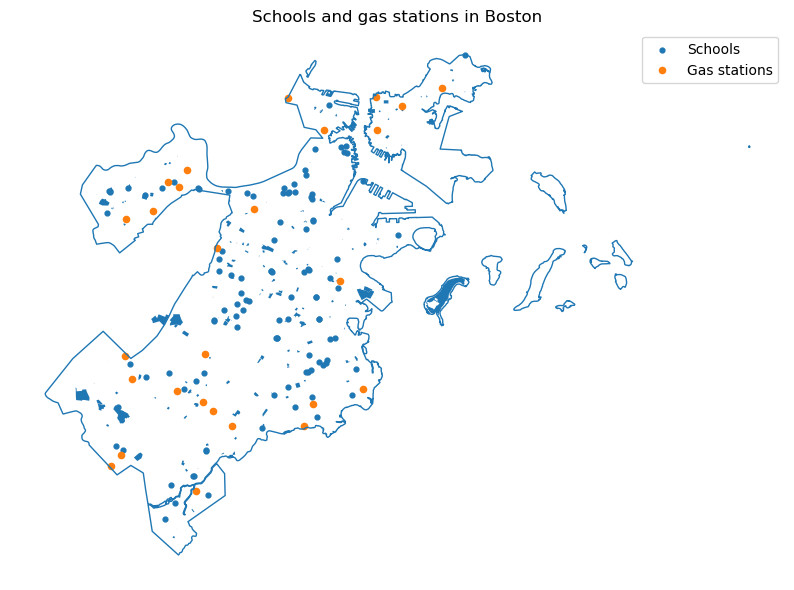

In [5]:
fig, ax = plt.subplots(figsize=(10, 10))

boston.boundary.plot(
    ax=ax,
    linewidth=1
)

schools.plot(
    ax=ax,
    markersize=12,
    label="Schools"
)

fuel.plot(
    ax=ax,
    markersize=20,
    label="Gas stations"
)

ax.set_title("Schools and gas stations in Boston")
ax.set_axis_off()
ax.legend()
plt.show()

# Decision 1 — Which gas stations violate the rule?

We first compute each gas station's minimum distance to any school.

Because some OSM objects are polygons rather than points, GeoPandas computes distance between the actual geometries.

In [6]:
distance_to_school = fuel.geometry.apply(
    lambda station:
        schools.geometry.distance(station).min()
)

fuel["nearest_school_m"] = distance_to_school

fuel[
    ["element", "nearest_school_m"]
].sort_values(
    "nearest_school_m"
).head(15)

,element,nearest_school_m
feature_id,,
fuel_28_BP,way,16.344538
fuel_36_US Gas,way,16.817808
fuel_43_Stan Hatoff's,way,23.196254
fuel_8_Shell,node,47.383312
fuel_9_Mobil,node,91.365677
fuel_2_Columbia Road Gulf,node,96.766745
fuel_29_Speedway,way,98.044988
fuel_41_Citgo,way,100.187359
fuel_49_Shell,way,171.630269


The workshop rule is:

> **Minimum school distance = 100 meters**

We can identify possible violations directly from the distance calculation. We will also reproduce the same logic spatially with buffers and a spatial join.

In [7]:
MIN_SCHOOL_DISTANCE = 100

fuel["violates_distance_rule"] = (
    fuel["nearest_school_m"]
    < MIN_SCHOOL_DISTANCE
)

affected_by_distance = (
    fuel[
        fuel["violates_distance_rule"]
    ]
    .sort_values("nearest_school_m")
)

affected_by_distance[
    ["element", "nearest_school_m"]
]

,element,nearest_school_m
feature_id,,
fuel_28_BP,way,16.344538
fuel_36_US Gas,way,16.817808
fuel_43_Stan Hatoff's,way,23.196254
fuel_8_Shell,node,47.383312
fuel_9_Mobil,node,91.365677
fuel_2_Columbia Road Gulf,node,96.766745
fuel_29_Speedway,way,98.044988


# Decision 2 — Create the protected area around schools

A **buffer** converts the legal distance rule into geometry.

Every location inside a school buffer is prohibited for a gas station under the workshop rule.

/opt/anaconda3/envs/papersPremier/lib/python3.12/site-packages/shapely/constructive.py:246: RuntimeWarning: invalid value encountered in buffer
  return lib.buffer(


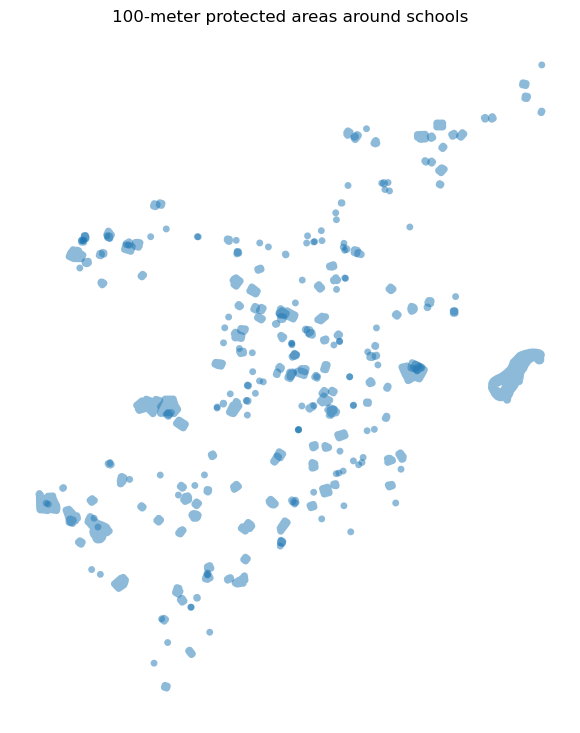

In [8]:
school_buffers = schools.copy()

school_buffers["geometry"] = (
    school_buffers.geometry
    .buffer(MIN_SCHOOL_DISTANCE)
)

school_buffers.plot(
    figsize=(9, 9),
    alpha=0.5
)

plt.title("100-meter protected areas around schools")
plt.axis("off")
plt.show()

# Decision 3 — Standardize gas-station geometries for intersection

Some gas stations are points and others are polygons. To avoid losing a station because only a point representation is available, point stations receive a small 10-meter footprint for the compliance check.

This is a modeling choice for the exercise, not an estimate of the real parcel boundary.

In [9]:
fuel_footprints = fuel.copy()

fuel_footprints["geometry"] = [
    geom.buffer(10)
    if geom.geom_type == "Point"
    else geom
    for geom in fuel.geometry
]

fuel_footprints.geometry.geom_type.value_counts()

Polygon    53
Name: count, dtype: int64

# Decision 4 — Spatially identify stations in the protected areas

A spatial join answers:

> Which gas-station geometries intersect at least one school protection buffer?

A station can intersect more than one school buffer, so we remove duplicate station IDs after the join.

In [11]:
gas_relocate = (
    fuel_footprints
    .sjoin(
        school_buffers[["geometry"]],
        how="inner",
        predicate="intersects"
    )
)

# One row per gas station
gas_relocate = (
    gas_relocate[
        ~gas_relocate.index.duplicated(
            keep="first"
        )
    ]
    .copy()
)

gas_relocate[
    ["element", "nearest_school_m"]
].sort_values(
    "nearest_school_m"
)

,element,nearest_school_m
feature_id_left,,
fuel_28_BP,way,16.344538
fuel_36_US Gas,way,16.817808
fuel_43_Stan Hatoff's,way,23.196254
fuel_8_Shell,node,47.383312
fuel_9_Mobil,node,91.365677
fuel_2_Columbia Road Gulf,node,96.766745
fuel_29_Speedway,way,98.044988


### Sanity check

The distance-based rule and the buffer/intersection rule should identify broadly consistent cases. Small differences can occur because point gas stations were given a 10-meter footprint for the intersection test.

In [12]:
print(
    "Distance-rule cases:",
    int(fuel["violates_distance_rule"].sum())
)

print(
    "Spatial-intersection cases:",
    len(gas_relocate)
)

Distance-rule cases: 7
Spatial-intersection cases: 7


/var/folders/ys/ndy0r6cs0xs8h17788sx08sh0000gn/T/ipykernel_3852/2427134582.py:21: UserWarning: Legend does not support handles for PatchCollection instances.
See: https://matplotlib.org/stable/tutorials/intermediate/legend_guide.html#implementing-a-custom-legend-handler
  ax.legend()
/var/folders/ys/ndy0r6cs0xs8h17788sx08sh0000gn/T/ipykernel_3852/2427134582.py:21: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


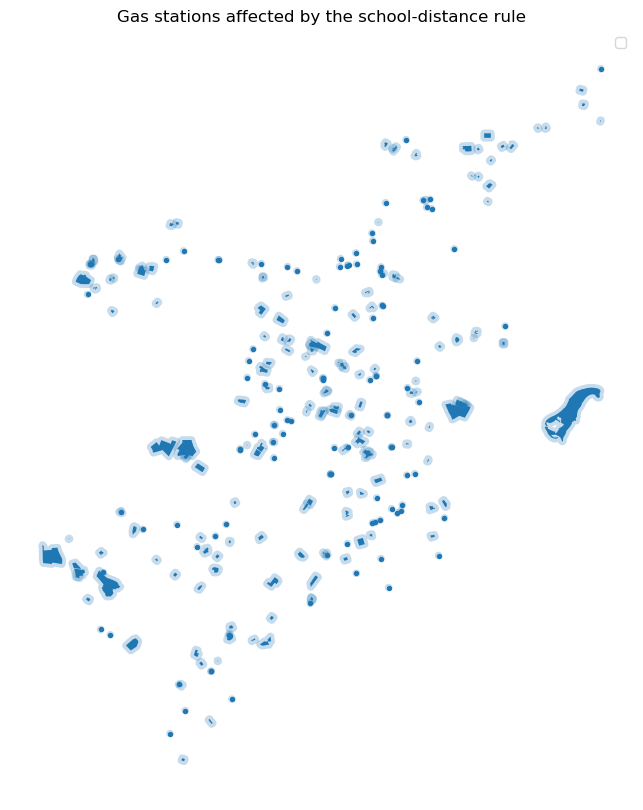

In [13]:
fig, ax = plt.subplots(figsize=(10, 10))

school_buffers.plot(
    ax=ax,
    alpha=0.25
)

schools.plot(
    ax=ax,
    markersize=8
)

gas_relocate.plot(
    ax=ax,
    markersize=35,
    label="Affected gas stations"
)

ax.set_title("Gas stations affected by the school-distance rule")
ax.set_axis_off()
ax.legend()
plt.show()

# Decision 5 — Where could the affected stations relocate?

A legally acceptable location is not automatically a useful location.

For a simple workshop exercise, candidate locations must satisfy three spatial conditions:

1. remain outside the school protection buffers;
2. remain at least 100 meters from existing gas stations;
3. lie on road types where a gas station location is more plausible.

This is a **screening procedure**, not a final siting decision. Zoning, parcel ownership, traffic engineering, environmental regulation, utilities, and commercial feasibility are not included.

In [14]:
# Download the drivable road network
G = ox.graph_from_place(
    place,
    network_type="drive"
)

_, streets = ox.graph_to_gdfs(G)

streets = streets.to_crs(
    TARGET_CRS
)

GAS_STATION_ROAD_TYPES = [
    "motorway",
    "trunk",
    "primary",
    "secondary",
    "tertiary",
    "motorway_link",
    "trunk_link",
    "primary_link",
    "secondary_link",
    "tertiary_link"
]

def has_suitable_highway(value):
    if isinstance(value, list):
        return any(
            item in GAS_STATION_ROAD_TYPES
            for item in value
        )

    return value in GAS_STATION_ROAD_TYPES

suitable_roads = streets[
    streets["highway"]
    .apply(has_suitable_highway)
].copy()

print(
    "Suitable road segments:",
    len(suitable_roads)
)

/opt/anaconda3/envs/papersPremier/lib/python3.12/site-packages/shapely/constructive.py:246: RuntimeWarning: invalid value encountered in buffer
  return lib.buffer(
/opt/anaconda3/envs/papersPremier/lib/python3.12/site-packages/shapely/predicates.py:878: RuntimeWarning: invalid value encountered in intersects
  return lib.intersects(a, b, **kwargs)
/opt/anaconda3/envs/papersPremier/lib/python3.12/site-packages/shapely/set_operations.py:451: RuntimeWarning: invalid value encountered in union
  return lib.union(a, b, **kwargs)
/opt/anaconda3/envs/papersPremier/lib/python3.12/site-packages/shapely/predicates.py:878: RuntimeWarning: invalid value encountered in intersects
  return lib.intersects(a, b, **kwargs)
/opt/anaconda3/envs/papersPremier/lib/python3.12/site-packages/shapely/set_operations.py:451: RuntimeWarning: invalid value encountered in union
  return lib.union(a, b, **kwargs)


Suitable road segments: 10536


## 6. Build the exclusion area

We combine:

- school buffers; and
- 100-meter buffers around all existing gas-station footprints.

Then we subtract those prohibited areas from the suitable road network. What remains is the spatial opportunity set considered by this simple model.

In [15]:
COMPETITION_DISTANCE = 100

fuel_buffers = fuel_footprints.copy()

fuel_buffers["geometry"] = (
    fuel_buffers.geometry
    .buffer(COMPETITION_DISTANCE)
)

exclusion = gpd.GeoDataFrame(
    geometry=[
        gpd.GeoSeries(
            pd.concat(
                [
                    school_buffers.geometry,
                    fuel_buffers.geometry
                ],
                ignore_index=True
            ),
            crs=TARGET_CRS
        ).union_all()
    ],
    crs=TARGET_CRS
)

candidate_roads = gpd.overlay(
    suitable_roads[
        ["highway", "geometry"]
    ],
    exclusion,
    how="difference",
    keep_geom_type=True
)

candidate_roads = (
    candidate_roads[
        ~candidate_roads.geometry.is_empty
    ]
    .copy()
)

print(
    "Candidate road pieces:",
    len(candidate_roads)
)

/opt/anaconda3/envs/papersPremier/lib/python3.12/site-packages/shapely/constructive.py:246: RuntimeWarning: invalid value encountered in buffer
  return lib.buffer(
/opt/anaconda3/envs/papersPremier/lib/python3.12/site-packages/shapely/set_operations.py:553: RuntimeWarning: invalid value encountered in unary_union
  return lib.unary_union(collections, **kwargs)
/opt/anaconda3/envs/papersPremier/lib/python3.12/site-packages/shapely/set_operations.py:100: RuntimeWarning: invalid value encountered in difference
  return lib.difference(a, b, **kwargs)


Candidate road pieces: 9229


## 7. Produce relocation candidates for each affected station

For each affected station, we find the nearest remaining road pieces and locate the nearest point on those pieces.

We keep three candidates per station so the municipality receives **options**, not an automatic relocation order.

In [16]:
candidate_rows = []

for station_id, station in gas_relocate.iterrows():

    origin = station.geometry.centroid

    distances = (
        candidate_roads.geometry
        .distance(origin)
        .sort_values()
    )

    for rank, road_idx in enumerate(
        distances.head(3).index,
        start=1
    ):

        road_geom = (
            candidate_roads
            .loc[road_idx, "geometry"]
        )

        candidate_point = nearest_points(
            origin,
            road_geom
        )[1]

        candidate_rows.append({
            "Station ID": station_id,
            "Candidate rank": rank,
            "Distance from current site (m)":
                distances.loc[road_idx],
            "geometry": candidate_point
        })

relocation_candidates = gpd.GeoDataFrame(
    candidate_rows,
    geometry="geometry",
    crs=TARGET_CRS
)

relocation_candidates.head(10)

,Station ID,Candidate rank,Distance from current site (m),geometry
0,fuel_2_Columbia Road Gulf,1,109.900011,POINT (236537.476 896665.332)
1,fuel_2_Columbia Road Gulf,2,109.900011,POINT (236537.476 896665.332)
2,fuel_2_Columbia Road Gulf,3,125.000161,POINT (236657.141 896848.101)
3,fuel_8_Shell,1,109.885674,POINT (237966.4 902573.324)
4,fuel_8_Shell,2,109.885674,POINT (237966.4 902573.324)
5,fuel_8_Shell,3,109.906576,POINT (237941.279 902573.199)
6,fuel_9_Mobil,1,109.879651,POINT (238975.253 903415.608)
7,fuel_9_Mobil,2,109.879651,POINT (238975.253 903415.608)
8,fuel_9_Mobil,3,109.883808,POINT (238889.251 903455.898)
9,fuel_28_BP,1,130.991857,POINT (239025.26 903359.491)


In [17]:
relocation_table = (
    relocation_candidates
    .drop(columns="geometry")
    .round({
        "Distance from current site (m)": 1
    })
)

relocation_table

,Station ID,Candidate rank,Distance from current site (m)
0,fuel_2_Columbia Road Gulf,1,109.9
1,fuel_2_Columbia Road Gulf,2,109.9
2,fuel_2_Columbia Road Gulf,3,125.0
3,fuel_8_Shell,1,109.9
4,fuel_8_Shell,2,109.9
5,fuel_8_Shell,3,109.9
6,fuel_9_Mobil,1,109.9
7,fuel_9_Mobil,2,109.9
8,fuel_9_Mobil,3,109.9
9,fuel_28_BP,1,131.0


## 8. Map the candidate relocation points

/var/folders/ys/ndy0r6cs0xs8h17788sx08sh0000gn/T/ipykernel_3852/3239777964.py:36: UserWarning: Legend does not support handles for PatchCollection instances.
See: https://matplotlib.org/stable/tutorials/intermediate/legend_guide.html#implementing-a-custom-legend-handler
  ax.legend()


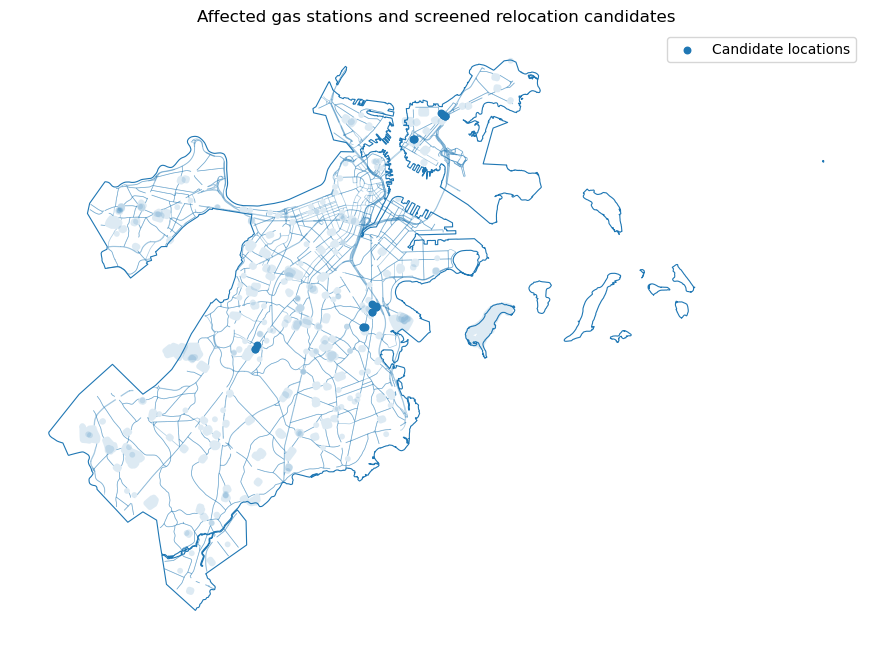

In [18]:
fig, ax = plt.subplots(figsize=(11, 11))

boston.boundary.plot(
    ax=ax,
    linewidth=0.8
)

candidate_roads.plot(
    ax=ax,
    linewidth=0.5,
    alpha=0.4
)

school_buffers.plot(
    ax=ax,
    alpha=0.15
)

gas_relocate.plot(
    ax=ax,
    markersize=40,
    label="Affected stations"
)

relocation_candidates.plot(
    ax=ax,
    markersize=22,
    label="Candidate locations"
)

ax.set_title(
    "Affected gas stations and screened relocation candidates"
)

ax.set_axis_off()
ax.legend()
plt.show()

# How to read the output

The analysis produces two forms of spatial intelligence:

- a **compliance list** identifying gas stations affected by the new rule;
- a **candidate-location table and map** identifying places that satisfy the spatial constraints included in the model.

The municipality should not interpret the candidate points as approved relocation sites. They are locations that pass the spatial screening rules used in this notebook.

Before any relocation decision, the municipality would still need information about zoning, parcels, ownership, traffic access, environmental restrictions, construction feasibility, utilities, neighborhood effects, and the legal interpretation of the regulation.

> **Decision boundary:** spatial analysis narrows the search space. The municipality makes the siting decision.

## Exercise

Modify one assumption and observe how the candidate set changes.

Examples:

- increase the school buffer from 100 to 150 meters;
- increase the minimum distance from existing gas stations;
- change the allowed road types;
- add another prohibited land-use layer.

Which assumptions most strongly affect the final opportunity set?